# 10. Modern Recurrent Neural Networks

The previous chapter introduced the key ideas behind recurrent neural networks (RNNs). However, just as with convolutional neural networks, there has been a tremendous amount of innovation in RNN architectures, culminating in several complex designs that have proven successful in practice. In particular, the most popular designs feature mechanisms for mitigating the notorious numerical instability faced by RNNs, as typified by vanishing and exploding gradients. Recall that in Section 9 we dealt with exploding gradients by applying a blunt gradient clipping heuristic. Despite the efficacy of this hack, it leaves open the problem of vanishing gradients.

## 10.1. Long Short-Term Memory (LSTM)

The term "long short-term memory" comes from the following intuition. Simple recurrent neural networks have *long-term memory* in the form of weights. The weights change slowly during training, encoding general knowledge about the data. They also have *short-term memory* in the form of ephemeral activations, which pass from each node to successive nodes. The LSTM model introduces an intermediate type of storage via the memory cell. A memory cell is a composite unit, built from simpler nodes in a specific connectivity pattern, with the novel inclusion of multiplicative nodes.

---
牧之：
- 有点意思，用传统计算模型中的电路逻辑，来指导神经网络的网络结构设计。
- 传统 RNN 的简单结构，无法额外表达一个输入对后续状态影响的深远程度，那么就改变了网络结构，增加了一些可以控制一个输入影响深远程度的结构，并且这些增加的结构是可以学习的。这也再次用到了“数据驱动”的范式，人类无法直接写出一个函数，那么就用数据去拟合它。

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 10.1.1. Gated Memory Cell

Each memory cell is equipped with an **internal state** and *a number of multiplicative gates* that determine whether (i) a given input should impact the internal state (the **input gate**), (ii) the internal state should be flushed to $0$ (the **forget gate**), and (iii) the internal state of a given neuron should be allowed to impact the cell's output (the **output gate**).

#### 10.1.1.1. Gated Hidden State

The key distinction between vanilla RNNs and LSTMs is that the latter support gating of the hidden state. This means that we have dedicated mechanisms for when a hidden state should be *updated* and also for when it should be *reset*. These mechanisms are learned and they address the concerns listed above.

#### 10.1.1.2. Input Gate, Forget Gate, and Output Gate

The data feeding into the LSTM gates are the input at the current time step and the hidden state of the previous time step, as illustrated in Fig. 10.1.1. Three fully connected layers with sigmoid activation functions compute the values of the input, forget, and output gates. As a result of the sigmoid activation, all values of the three gates are in the range of $(0, 1)$. Additionally, we require an *input node*, typically computed with a *tanh* activation function. Intuitively, the **input gate** determines how much of the input node's value should be added to the current memory cell internal state. The **forget gate** determines whether to keep the current value of the memory or flush it. And the **output gate** determines whether the memory cell should influence the output at the current time step.

![](https://d2l.ai/_images/lstm-0.svg)
<center>Fig. 10.1.1 Computing the input gate, the forget gate, and the output gate in an LSTM model.</center>

Mathematically, suppose that there are $h$ hidden units, the batch size is $n$, and the number of inputs is $d$. Thus, the input is $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ and the hidden state of the previous time step is $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$. Correspondingly, the gates at time step $t$ are defined as follows: the input gate is $\mathbf{I}_t \in \mathbb{R}^{n \times h}$, the forget gate is $\mathbf{F}_t \in \mathbb{R}^{n \times h}$, and the output gate is $\mathbf{O}_t \in \mathbb{R}^{n \times h}$. They are calculated as follows:

$$ \begin{aligned} \mathbf{I}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xi}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hi}} + \mathbf{b}_\textrm{i}),\\ \mathbf{F}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xf}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hf}} + \mathbf{b}_\textrm{f}),\\ \mathbf{O}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xo}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{ho}} + \mathbf{b}_\textrm{o}), \end{aligned} \tag{10.1.1}$$

where $\mathbf{W}_{\textrm{xi}}, \mathbf{W}_{\textrm{xf}}, \mathbf{W}_{\textrm{xo}} \in \mathbb{R}^{d \times h}$ and $\mathbf{W}_{\textrm{hi}}, \mathbf{W}_{\textrm{hf}}, \mathbf{W}_{\textrm{ho}} \in \mathbb{R}^{h \times h}$ are weight parameters and $\mathbf{b}_\textrm{i}, \mathbf{b}_\textrm{f}, \mathbf{b}_\textrm{o} \in \mathbb{R}^{1 \times h}$ are bias parameters. Note that broadcasting (see Section 2.1.4) is triggered during the summation. We use sigmoid functions (as introduced in Section 5.1) to map the input values to the interval $(0, 1)$.

#### 10.1.1.3. Input Node

Next we design the memory cell. Since we have not specified the action of the various gates yet, we first introduce the **input node** $\tilde{\mathbf{C}}_t \in \mathbb{R}^{n \times h}$. Its computation is similar to that of the three gates described above, but uses a $\tanh$ function with a value range for $(-1, 1)$ as the activation function. This leads to the following equation at time step $t$:

$$\tilde{\mathbf{C}}_t = \textrm{tanh}(\mathbf{X}_t \mathbf{W}_{\textrm{xc}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hc}} + \mathbf{b}_\textrm{c}), \tag{10.1.2}$$

where $\mathbf{W}_{\textrm{xc}} \in \mathbb{R}^{d \times h}$ and $\mathbf{W}_{\textrm{hc}} \in \mathbb{R}^{h \times h}$ are weight parameters and $\mathbf{b}_\textrm{c} \in \mathbb{R}^{1 \times h}$ is a bias parameter.

A quick illustration of the input node is shown in Fig. 10.1.2.

![](https://d2l.ai/_images/lstm-1.svg)
<center>Fig. 10.1.2 Computing the input node in an LSTM model.</center>

#### 10.1.1.4. Memory Cell Internal State

In LSTMs, the input gate $\mathbf{I}_t$ governs how much we take new data into account via $\tilde{\mathbf{C}}_t$ and the forget gate $\mathbf{F}_t$ addresses how much of the old cell internal state $\mathbf{C}_{t-1} \in \mathbb{R}^{n \times h}$ we retain. Using the Hadamard (elementwise) product operator $\odot$ we arrive at the following update equation:

$$\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t. \tag{10.1.3}$$

If the forget gate is always 1 and the input gate is always 0, the memory cell internal state $\mathbf{C}_{t-1}$ will remain constant forever, passing unchanged to each subsequent time step. However, input gates and forget gates give the model the flexibility of being able to learn when to keep this value unchanged and when to perturb it in response to subsequent inputs. In practice, this design alleviates the vanishing gradient problem, resulting in models that are much easier to train, especially when facing datasets with long sequence lengths.

We thus arrive at the flow diagram in Fig. 10.1.3.

![](https://d2l.ai/_images/lstm-2.svg)
<center>Fig. 10.1.3 Computing the memory cell internal state in an LSTM model.</center>

#### 10.1.1.5. Hidden State

Last, we need to define how to compute the output of the memory cell, i.e., the hidden state $\mathbf{H}_t \in \mathbb{R}^{n \times h}$, as seen by other layers. This is where the output gate comes into play. In LSTMs, we first apply $\tanh$ to the memory cell internal state and then apply another point-wise multiplication, this time with the output gate. This ensures that the values of $\mathbf{H}_t$ are always in the interval $(-1, 1)$:

$$\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t). \tag{10.1.4}$$

Whenever the output gate is close to 1, we allow the memory cell internal state to impact the subsequent layers uninhibited, whereas for output gate values close to 0, we prevent the current memory from impacting other layers of the network at the current time step. Note that a memory cell can accrue information across many time steps without impacting the rest of the network (as long as the output gate takes values close to 0), and then suddenly impact the network at a subsequent time step as soon as the output gate flips from values close to 0 to values close to 1. Fig. 10.1.4 has a graphical illustration of the data flow.

![](https://d2l.ai/_images/lstm-3.svg)
<center>Fig. 10.1.4 Computing the hidden state in an LSTM model.</center>

---
牧之：输出们趋于 0，那么影响的是包含当前输入和长期记忆的所有状态，这些信息少了，貌似也没其他信息补上可以来预测。除非说因为输出门参与的是哈达门运算，可以学会控制平衡当前输入和长期记忆的局部权重。但总觉得存疑。

### 10.1.2. Implementation from Scratch

#### 10.1.2.1. Initializing Model Parameters

In [ ]:
class LSTMScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_xi, self.W_hi, self.b_i = triple()  # Input gate
        self.W_xf, self.W_hf, self.b_f = triple()  # Forget gate
        self.W_xo, self.W_ho, self.b_o = triple()  # Output gate
        self.W_xc, self.W_hc, self.b_c = triple()  # Input node

The actual model is defined as described above, consisting of three gates and an input node. Note that only the hidden state is passed to the output layer.

In [ ]:
@d2l.add_to_class(LSTMScratch)
def forward(self, inputs, H_C=None):
    if H_C is None:
        # Initial state with shape: (batch_size, num_hiddens)
        H = torch.zeros((inputs.shape[1], self.num_hiddens),
                        device=inputs.device)
        C = torch.zeros((inputs.shape[1], self.num_hiddens),
                        device=inputs.device)
    else:
        H, C = H_C
    outputs = []
    for X in inputs:
        I = torch.sigmoid(torch.matmul(X, self.W_xi) +
                          torch.matmul(H, self.W_hi) + self.b_i)
        F = torch.sigmoid(torch.matmul(X, self.W_xf) +
                          torch.matmul(H, self.W_hf) + self.b_f)
        O = torch.sigmoid(torch.matmul(X, self.W_xo) +
                          torch.matmul(H, self.W_ho) + self.b_o)
        C_tilde = torch.tanh(torch.matmul(X, self.W_xc) +
                             torch.matmul(H, self.W_hc) + self.b_c)
        C = F * C + I * C_tilde
        H = O * torch.tanh(C)
        outputs.append(H)
    return outputs, (H, C)

#### 10.1.2.2. Training and Prediction

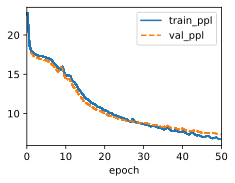

In [ ]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
lstm = LSTMScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLMScratch(lstm, vocab_size=len(data.vocab), lr=4)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 10.1.3. Concise Implementation

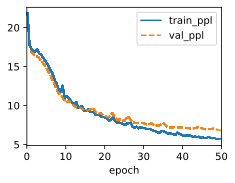

In [ ]:
class LSTM(d2l.RNN):
    def __init__(self, num_inputs, num_hiddens):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.LSTM(num_inputs, num_hiddens)

    def forward(self, inputs, H_C=None):
        return self.rnn(inputs, H_C)

lstm = LSTM(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLM(lstm, vocab_size=len(data.vocab), lr=4)
trainer.fit(model, data)

In [ ]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has of the the the the '

LSTMs are the prototypical latent variable autoregressive model with nontrivial state control. Many variants thereof have been proposed over the years, e.g., multiple layers, residual connections, different types of regularization. However, training LSTMs and other sequence models (such as GRUs) is quite costly because of the long range dependency of the sequence. Later we will encounter alternative models such as Transformers that can be used in some cases.

### 10.1.4. Summary

While LSTMs were published in 1997, they rose to great prominence with some victories in prediction competitions in the mid-2000s, and became the dominant models for sequence learning from 2011 until the rise of Transformer models, starting in 2017. Even Tranformers owe some of their key ideas to architecture design innovations introduced by the LSTM.

LSTMs have three types of gates: input gates, forget gates, and output gates that control the flow of information. The hidden layer output of LSTM includes the hidden state and the memory cell internal state. Only the hidden state is passed into the output layer while the memory cell internal state remains entirely internal. LSTMs can alleviate vanishing and exploding gradients.

### 10.1.5. Exercises

1. Adjust the hyperparameters and analyze their influence on running time, perplexity, and the output sequence.

1. How would you need to change the model to generate proper words rather than just sequences of characters?

1. Compare the computational cost for GRUs, LSTMs, and regular RNNs for a given hidden dimension. Pay special attention to the training and inference cost.

1. Since the candidate memory cell ensures that the value range is between $-1$ and $1$ by  using the $\tanh$ function, why does the hidden state need to use the $\tanh$ function again to ensure that the output value range is between $-1$ and $1$?

1. Implement an LSTM model for time series prediction rather than character sequence prediction.

## 10.2. Gated Recurrent Units (GRU)

As RNNs and particularly the LSTM architecture (Section 10.1) rapidly gained popularity during the 2010s, a number of researchers began to experiment with simplified architectures in hopes of retaining the key idea of incorporating an internal state and multiplicative gating mechanisms but with the aim of speeding up computation. The gated recurrent unit (GRU) (Cho et al., 2014) offered a streamlined version of the LSTM memory cell that often achieves comparable performance but with the advantage of being faster to compute (Chung et al., 2014).

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 10.2.1. Reset Gate and Update Gate

Here, the LSTM's three gates are replaced by two: the **reset gate** and the **update gate**. As with LSTMs, these gates are given sigmoid activations, forcing their values to lie in the interval $(0, 1)$. Intuitively, *the reset gate controls how much of the previous state we might still want to remember*. Likewise, *an update gate would allow us to control how much of the new state is just a copy of the old one*. Fig. 10.2.1 illustrates the inputs for both the reset and update gates in a GRU, given the input of the current time step and the hidden state of the previous time step. The outputs of the gates are given by two fully connected layers with a sigmoid activation function.

![](https://d2l.ai/_images/gru-1.svg)
<center>Fig. 10.2.1 Computing the reset gate and the update gate in a GRU model.</center>

Mathematically, for a given time step $t$, suppose that the input is a minibatch $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ (number of examples $=n$; number of inputs $=d$) and the hidden state of the previous time step is $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$ (number of hidden units $=h$). Then the reset gate $\mathbf{R}_t \in \mathbb{R}^{n \times h}$ and update gate $\mathbf{Z}_t \in \mathbb{R}^{n \times h}$ are computed as follows:

$$ \begin{aligned} \mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xr}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hr}} + \mathbf{b}_\textrm{r}),\\ \mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xz}} + \mathbf{H}_{t-1} \mathbf{W}_{\textrm{hz}} + \mathbf{b}_\textrm{z}), \end{aligned} \tag{10.2.1}$$

where $\mathbf{W}_{\textrm{xr}}, \mathbf{W}_{\textrm{xz}} \in \mathbb{R}^{d \times h}$ and $\mathbf{W}_{\textrm{hr}}, \mathbf{W}_{\textrm{hz}} \in \mathbb{R}^{h \times h}$ are weight parameters and $\mathbf{b}_\textrm{r}, \mathbf{b}_\textrm{z} \in \mathbb{R}^{1 \times h}$ are bias parameters.

### 10.2.2. Candidate Hidden State

Next, we integrate the reset gate $\mathbf{R}_t$ with the regular updating mechanism in (9.4.5), leading to the following *candidate hidden state* $\tilde{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$ at time step $t$:

$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \left(\mathbf{R}_t \odot \mathbf{H}_{t-1}\right) \mathbf{W}_{\textrm{hh}} + \mathbf{b}_\textrm{h}), \tag{10.2.2}$$

where $\mathbf{W}_{\textrm{xh}} \in \mathbb{R}^{d \times h}$ and $\mathbf{W}_{\textrm{hh}} \in \mathbb{R}^{h \times h}$ are weight parameters, $\mathbf{b}_\textrm{h} \in \mathbb{R}^{1 \times h}$ is the bias, and the symbol $\odot$ is the Hadamard (elementwise) product operator. Here we use a tanh activation function.

The result is a *candidate*, since we still need to incorporate the action of the update gate. Comparing with (9.4.5), the influence of the previous states can now be reduced with the elementwise multiplication of $\mathbf{R}_t$ and $\mathbf{H}_{t-1}$ in (10.2.2). Whenever the entries in the reset gate $\mathbf{R}_t$ are close to 1, we recover a vanilla RNN such as that in (9.4.5). For all entries of the reset gate $\mathbf{R}_t$ that are close to 0, the candidate hidden state is the result of an MLP with $\mathbf{X}_t$ as input. Any pre-existing hidden state is thus *reset* to defaults.

Fig. 10.2.2 illustrates the computational flow after applying the reset gate.

![](https://d2l.ai/_images/gru-2.svg)
<center>Fig. 10.2.2 Computing the candidate hidden state in a GRU model.</center>

### 10.2.3. Hidden State

Finally, we need to incorporate the effect of the update gate $\mathbf{Z}_t$. This determines the extent to which the new hidden state $\mathbf{H}_t \in \mathbb{R}^{n \times h}$ matches the old state $\mathbf{H}_{t-1}$ compared with how much it resembles the new candidate state $\tilde{\mathbf{H}}_t$. The update gate $\mathbf{Z}_t$ can be used for this purpose, simply by taking elementwise convex combinations of $\mathbf{H}_{t-1}$ and $\tilde{\mathbf{H}}_t$. This leads to the final update equation for the GRU:

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1}  + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t. \tag{10.2.3}$$

Whenever the update gate $\mathbf{Z}_t$ is close to 1, we simply retain the old state. In this case the information from $\mathbf{X}_t$ is ignored, effectively skipping time step $t$ in the dependency chain. By contrast, whenever $\mathbf{Z}_t$ is close to 0, the new latent state $\mathbf{H}_t$ approaches the candidate latent state $\tilde{\mathbf{H}}_t$. Fig. 10.2.3 shows the computational flow after the update gate is in action.

![](https://d2l.ai/_images/gru-3.svg)
<center>Fig. 10.2.3 Computing the hidden state in a GRU model.</center>

In summary, GRUs have the following two distinguishing features:
* Reset gates help capture short-term dependencies in sequences.
* Update gates help capture long-term dependencies in sequences.

---
牧之：
- 式 (10.2.2) 和式 (10.2.3) 是更高层级的抽象，前者可以统一表达 RNN 和 MLP 效果，后者可以表达更为丰富的信息传播过程。
- 式 (10.2.2) 和式 (10.2.3) 的组合使用，可以表达更为丰富的应用场景：
  - $\mathbf{R}_t$ = 0，$\tilde{\mathbf{H}}_t$ 退化成 MLP（候选隐状态反应的只有当前时间步输入 $\mathbf{X}_t$ 的信息）；$\mathbf{Z}_t$ = 0，只传递候选隐状态，历史隐状态被重置。综合效果：当前时间步是划时代事件，给一段历史画上了句号，切断了后续时间的前向依赖。例如，改朝换代。
  - $\mathbf{R}_t$ = 0，$\tilde{\mathbf{H}}_t$ 退化成 MLP（候选隐状态反应的只有当前时间步输入 $\mathbf{X}_t$ 的信息）；$\mathbf{Z}_t$ = 1，跳过了候选隐状态，但历史隐状态被保留继续向后传播。综合效果：貌似 $\tilde{\mathbf{H}}_t$ 的计算浪费了。
  - $\mathbf{R}_t$ = 1，$\tilde{\mathbf{H}}_t$ 退化成 RNN；$\mathbf{Z}_t$ = 0，只传递候选隐状态，历史隐状态被重置。综合效果：真正的 RNN。例如：正常平淡的生活。
  - $\mathbf{R}_t$ = 1，$\tilde{\mathbf{H}}_t$ 退化成 RNN；$\mathbf{Z}_t$ = 1，跳过了候选隐状态，但历史隐状态被保留继续向后传播。综合效果：貌似 $\tilde{\mathbf{H}}_t$ 的计算浪费了。

能否建模如下情况：
- 当前事件对当下预测不怎么重要，但其导致的隐状态随着时间推移，对后续预测会很重要。

### 10.2.4. Implementation from Scratch

#### 10.2.4.1. Initializing Model Parameters

In [ ]:
class GRUScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_xz, self.W_hz, self.b_z = triple()  # Update gate
        self.W_xr, self.W_hr, self.b_r = triple()  # Reset gate
        self.W_xh, self.W_hh, self.b_h = triple()  # Candidate hidden state

#### 10.2.4.2. Defining the Model

In [ ]:
@d2l.add_to_class(GRUScratch)
def forward(self, inputs, H=None):
    if H is None:
        # Initial state with shape: (batch_size, num_hiddens)
        H = torch.zeros((inputs.shape[1], self.num_hiddens),
                        device=inputs.device)
    outputs = []
    for X in inputs:
        Z = torch.sigmoid(torch.matmul(X, self.W_xz) +
                          torch.matmul(H, self.W_hz) + self.b_z)
        R = torch.sigmoid(torch.matmul(X, self.W_xr) +
                          torch.matmul(H, self.W_hr) + self.b_r)
        H_tilde = torch.tanh(torch.matmul(X, self.W_xh) +
                             torch.matmul(R * H, self.W_hh) + self.b_h)
        H = Z * H + (1 - Z) * H_tilde
        outputs.append(H)
    return outputs, H

### 10.2.4.3. Training

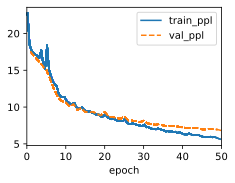

In [ ]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
gru = GRUScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLMScratch(gru, vocab_size=len(data.vocab), lr=4)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 10.2.5. Concise Implementation

In [ ]:
class GRU(d2l.RNN):
    def __init__(self, num_inputs, num_hiddens):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.GRU(num_inputs, num_hiddens)

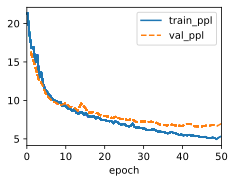

In [ ]:
gru = GRU(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLM(gru, vocab_size=len(data.vocab), lr=4)
trainer.fit(model, data)

In [ ]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has in insions of the n'

### 10.2.6. Summary

Compared with LSTMs, GRUs achieve similar performance but tend to be lighter computationally. Generally, compared with simple RNNs, gated RNNS, just like LSTMs and GRUs, can better capture dependencies for sequences with large time step distances. GRUs contain basic RNNs as their extreme case whenever the reset gate is switched on. They can also skip subsequences by turning on the update gate.

### 10.2.7. Exercises

1. Assume that we only want to use the input at time step $t'$ to predict the output at time step $t > t'$. What are the best values for the reset and update gates for each time step?

1. Adjust the hyperparameters and analyze their influence on running time, perplexity, and the output sequence.

1. Compare runtime, perplexity, and the output strings for `rnn.RNN` and `rnn.GRU` implementations with each other.

1. What happens if you implement only parts of a GRU, e.g., with only a reset gate or only an update gate?

## 10.3. Deep Recurrent Neural Networks

The standard method for building this sort of deep RNN is strikingly simple: we stack the RNNs on top of each other. Given a sequence of length $T$, the first RNN produces a sequence of outputs, also of length $T$. These, in turn, constitute the inputs to the next RNN layer. In this short section, we illustrate this design pattern and present a simple example for how to code up such stacked RNNs. Below, in Fig. 10.3.1, we illustrate a deep RNN with $L$ hidden layers. Each hidden state operates on a sequential input and produces a sequential output. Moreover, any RNN cell (white box in Fig. 10.3.1) at each time step depends on both *the same layer's value at the previous time step* and *the previous layer's value at the same time step*.

![](https://d2l.ai/_images/deep-rnn.svg)
<center>Fig. 10.3.1 Architecture of a deep RNN.</center>

Formally, suppose that we have a minibatch input $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ (number of examples $=n$; number of inputs in each example $=d$) at time step $t$. At the same time step, let the hidden state of the $l^\textrm{th}$ hidden layer ($l=1,\ldots,L$) be $\mathbf{H}_t^{(l)} \in \mathbb{R}^{n \times h}$ (number of hidden units $=h$) and the output layer variable be $\mathbf{O}_t \in \mathbb{R}^{n \times q}$ (number of outputs: $q$). Setting $\mathbf{H}_t^{(0)} = \mathbf{X}_t$, the hidden state of the $l^\textrm{th}$ hidden layer that uses the activation function $\phi_l$ is calculated as follows:

$$\mathbf{H}_t^{(l)} = \phi_l(\mathbf{H}_t^{(l-1)} \mathbf{W}_{\textrm{xh}}^{(l)} + \mathbf{H}_{t-1}^{(l)} \mathbf{W}_{\textrm{hh}}^{(l)}  + \mathbf{b}_\textrm{h}^{(l)}), \tag{10.3.1}$$

where the weights $\mathbf{W}_{\textrm{xh}}^{(l)} \in \mathbb{R}^{h \times h}$ and $\mathbf{W}_{\textrm{hh}}^{(l)} \in \mathbb{R}^{h \times h}$, together with the bias $\mathbf{b}_\textrm{h}^{(l)} \in \mathbb{R}^{1 \times h}$, are the model parameters of the $l^\textrm{th}$ hidden layer.

At the end, the calculation of the output layer is only based on the hidden state of the final $L^\textrm{th}$ hidden layer:

$$\mathbf{O}_t = \mathbf{H}_t^{(L)} \mathbf{W}_{\textrm{hq}} + \mathbf{b}_\textrm{q}, \tag{10.3.2}$$

where the weight $\mathbf{W}_{\textrm{hq}} \in \mathbb{R}^{h \times q}$ and the bias $\mathbf{b}_\textrm{q} \in \mathbb{R}^{1 \times q}$ are the model parameters of the output layer.

Just as with MLPs, the number of hidden layers $L$ and the number of hidden units $h$ are hyperparameters that we can tune. Common RNN layer widths ($h$) are in the range $(64, 2056)$, and common depths ($L$) are in the range $(1, 8)$. In addition, we can easily get a deep-gated RNN by replacing the hidden state computation in (10.3.1) with that from an LSTM or a GRU.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 10.3.1. Implementation from Scratch

To implement a multilayer RNN from scratch, we can treat each layer as an `RNNScratch` instance with its own learnable parameters.

In [ ]:
class StackedRNNScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, num_layers, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.rnns = nn.Sequential(*[d2l.RNNScratch(
            num_inputs if i==0 else num_hiddens, num_hiddens, sigma)
                                    for i in range(num_layers)])

The multilayer forward computation simply performs forward computation layer by layer.

In [ ]:
@d2l.add_to_class(StackedRNNScratch)
def forward(self, inputs, Hs=None):
    outputs = inputs
    if Hs is None: Hs = [None] * self.num_layers
    for i in range(self.num_layers):
        outputs, Hs[i] = self.rnns[i](outputs, Hs[i])
        outputs = torch.stack(outputs, 0)
    Hs = torch.stack(Hs, 0)  # Lancer add this to be identical with concise version
    return outputs, Hs

---
牧之：
- 单层 RNN 的循环层输出的 `outputs` 的形状：一个长度为 `num_steps` 的 List，其每个元素的形状为 `(batch_size, num_hiddens)`。
- 与之相比，深度 RNN 的循环层输出的 `outputs` 形状有所变化，它通过 `outputs = torch.stack(outputs, 0)` 将这个 List 在 dim-0 堆叠，形状变为：`(num_steps, batch_size, num_hiddens)`。
  - 这里为什么要做这个堆叠呢？是为了复用代码。在深度 RNN，循环层前一层的输出会作为下一层的输入，而循环层的输入需要 `(num_steps, batch_size, num_inputs)` 的形状。这行适配代码可以把循环层输出的形状重新调整为循环层输入要求的形状。
- 单层 RNN 的循环层输出的隐状态的形状：`(batch_size, num_hiddens)`。
- 与之相比，这里循环层输出的隐状态形状有所变化，其形状为一个长度为 `num_layers` 的 List，其每个元素形状为 `(batch_size, num_hiddens)`。
  - 通过后续阅读发现，这个 Scratch 实现版与 Concise 实现版在此处并不一致，Concise 实现版输出的隐状态形状为 `(num_layers, batch_size, num_hiddens)`，相当于 Scratch 实现版少了一条 `stack` 语句。在上述代码做了修正。

In [ ]:
# Experiment
num_steps = 6
batch_size = 4
num_inputs = 10
num_hidden = 32
num_layers = 2

rnn_block = StackedRNNScratch(
              num_inputs=num_inputs,
              num_hiddens=num_hidden,
              num_layers=num_layers
            )

X = torch.ones((num_steps, batch_size, num_inputs))

output, state = rnn_block(X)

print(f"output.shape: {output.shape}")
print(f"state.shape: {state.shape}")

output.shape: torch.Size([6, 4, 32])
state.shape: torch.Size([2, 4, 32])


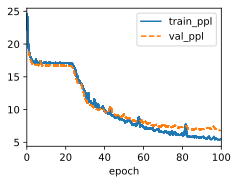

In [ ]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn_block = StackedRNNScratch(num_inputs=len(data.vocab),
                              num_hiddens=32, num_layers=2)
model = d2l.RNNLMScratch(rnn_block, vocab_size=len(data.vocab), lr=2)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 10.3.2. Concise Implementation

The code generalizes the one we used previously in Section 10.2, letting us specify the number of layers explicitly rather than picking the default of only one layer.

In [ ]:
class GRU(d2l.RNN):  #@ save
    """The multilayer GRU model."""
    def __init__(self, num_inputs, num_hiddens, num_layers, dropout=0):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.GRU(num_inputs, num_hiddens, num_layers,
                          dropout=dropout)

In [ ]:
# Experiment
num_steps = 6
batch_size = 4
num_inputs = 10
num_hidden = 32
num_layers = 2

gru = GRU(num_inputs=num_inputs, num_hiddens=num_hidden, num_layers=num_layers)

X = torch.ones((num_steps, batch_size, num_inputs))

output, state = gru(X)

print(f"output.shape: {output.shape}")
print(f"state.shape: {state.shape}")

output.shape: torch.Size([6, 4, 32])
state.shape: torch.Size([2, 4, 32])


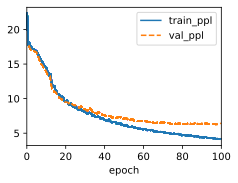

In [ ]:
gru = GRU(num_inputs=len(data.vocab), num_hiddens=32, num_layers=2)
model = d2l.RNNLM(gru, vocab_size=len(data.vocab), lr=2)
trainer.fit(model, data)

In [ ]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has a moment and four d'

### 10.3.3. Summary

In deep RNNs, the hidden state information is passed to the next time step of the current layer and the current time step of the next layer. There exist many different flavors of deep RNNs, such as LSTMs, GRUs, or vanilla RNNs. Conveniently, these models are all available as parts of the high-level APIs of deep learning frameworks. Initialization of models requires care. Overall, deep RNNs require considerable amount of work (such as learning rate and clipping) to ensure proper convergence.

### 10.3.4. Exercises

1. Replace the GRU by an LSTM and compare the accuracy and training speed.

1. Increase the training data to include multiple books. How low can you go on the perplexity scale?

1. Would you want to combine sources of different authors when modeling text? Why is this a good idea? What could go wrong?

## 10.4. Bidirectional Recurrent Neural Networks

Another common task—often useful as a pretraining exercise prior to fine-tuning a model on an actual task of interest—is to mask out random tokens in a text document and then to train a sequence model to predict the values of the missing tokens. Note that depending on what comes after the blank, the likely value of the missing token changes dramatically:

...

Fortunately, a simple technique transforms any unidirectional RNN into a bidirectional RNN (Schuster and Paliwal, 1997). We simply implement two unidirectional RNN layers chained together in opposite directions and acting on the same input (Fig. 10.4.1). For the first RNN layer, the first input is $\mathbf{x}_1$ and the last input is $\mathbf{x}_T$, but for the second RNN layer, the first input is $\mathbf{x}_T$ and the last input is $\mathbf{x}_1$. To produce the output of this bidirectional RNN layer, we simply concatenate together the corresponding outputs of the two underlying unidirectional RNN layers.

![](http://d2l.ai/_images/birnn.svg)
<center>Fig. 10.4.1 Architecture of a bidirectional RNN.</center>

Formally for any time step $t$, we consider a minibatch input $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ (number of examples $=n$; number of inputs in each example $=d$) and let the hidden layer activation function be $\phi$. In the bidirectional architecture, the forward and backward hidden states for this time step are $\overrightarrow{\mathbf{H}}_t  \in \mathbb{R}^{n \times h}$ and $\overleftarrow{\mathbf{H}}_t  \in \mathbb{R}^{n \times h}$, respectively, where $h$ is the number of hidden units. The forward and backward hidden state updates are as follows:

$$ \begin{aligned} \overrightarrow{\mathbf{H}}_t &= \phi(\mathbf{X}_t \mathbf{W}_{\textrm{xh}}^{(f)} + \overrightarrow{\mathbf{H}}_{t-1} \mathbf{W}_{\textrm{hh}}^{(f)}  + \mathbf{b}_\textrm{h}^{(f)}),\\ \overleftarrow{\mathbf{H}}_t &= \phi(\mathbf{X}_t \mathbf{W}_{\textrm{xh}}^{(b)} + \overleftarrow{\mathbf{H}}_{t+1} \mathbf{W}_{\textrm{hh}}^{(b)}  + \mathbf{b}_\textrm{h}^{(b)}), \end{aligned} $$

where the weights $\mathbf{W}_{\textrm{xh}}^{(f)} \in \mathbb{R}^{d \times h}, \mathbf{W}_{\textrm{hh}}^{(f)} \in \mathbb{R}^{h \times h}, \mathbf{W}_{\textrm{xh}}^{(b)} \in \mathbb{R}^{d \times h}, \textrm{ and } \mathbf{W}_{\textrm{hh}}^{(b)} \in \mathbb{R}^{h \times h}$, and the biases $\mathbf{b}_\textrm{h}^{(f)} \in \mathbb{R}^{1 \times h}$ and $\mathbf{b}_\textrm{h}^{(b)} \in \mathbb{R}^{1 \times h}$ are all the model parameters.

Next, we concatenate the forward and backward hidden states $\overrightarrow{\mathbf{H}}_t$ and $\overleftarrow{\mathbf{H}}_t$ to obtain the hidden state $\mathbf{H}_t \in \mathbb{R}^{n \times 2h}$ for feeding into the output layer. In deep bidirectional RNNs with multiple hidden layers, such information is passed on as *input* to the next bidirectional layer. Last, the output layer computes the output $\mathbf{O}_t \in \mathbb{R}^{n \times q}$ (number of outputs $=q$):

$$\mathbf{O}_t = \mathbf{H}_t \mathbf{W}_{\textrm{hq}} + \mathbf{b}_\textrm{q}.$$

Here, the weight matrix $\mathbf{W}_{\textrm{hq}} \in \mathbb{R}^{2h \times q}$ and the bias $\mathbf{b}_\textrm{q} \in \mathbb{R}^{1 \times q}$ are the model parameters of the output layer. While technically, the two directions can have different numbers of hidden units, this design choice is seldom made in practice. We now demonstrate a simple implementation of a bidirectional RNN.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 10.4.1. Implementation from Scratch

To implement a bidirectional RNN from scratch, we can include two unidirectional `RNNScratch` instances with separate learnable parameters.

In [ ]:
class BiRNNScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.f_rnn = d2l.RNNScratch(num_inputs, num_hiddens, sigma)
        self.b_rnn = d2l.RNNScratch(num_inputs, num_hiddens, sigma)
        self.num_hiddens *= 2  # The output dimension will be doubled

States of forward and backward RNNs are updated separately, while outputs of these two RNNs are concatenated.

In [ ]:
# Experimemt
import torch

num_steps = 4
batch_size = 2
num_hiddens = 6

f_outputs = [torch.arange(i * batch_size * num_hiddens + 1,
                          (i + 1) * batch_size * num_hiddens + 1)
                              .reshape(batch_size, num_hiddens)
                                  for i in range(num_steps)]

for i, output in enumerate(f_outputs):
    print(f"f_outputs, step {i + 1}:")
    print(output)
print("")

b_outputs = [torch.arange(i * batch_size * num_hiddens + 1,
                          (i + 1) * batch_size * num_hiddens + 1)
                              .reshape(batch_size, num_hiddens)
                                  for i in range(num_steps)]
b_outputs.reverse()

for i, output in enumerate(b_outputs):
    print(f"b_outputs, step {i + 1}:")
    print(output)
print("")

outputs = [torch.cat((f, b), -1) for f, b in zip(f_outputs, reversed(b_outputs))]

for i, output in enumerate(outputs):
    print(f"outputs, step {i + 1}:")
    print(output)

f_outputs, step 1:
tensor([[ 1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12]])
f_outputs, step 2:
tensor([[13, 14, 15, 16, 17, 18],
        [19, 20, 21, 22, 23, 24]])
f_outputs, step 3:
tensor([[25, 26, 27, 28, 29, 30],
        [31, 32, 33, 34, 35, 36]])
f_outputs, step 4:
tensor([[37, 38, 39, 40, 41, 42],
        [43, 44, 45, 46, 47, 48]])

b_outputs, step 1:
tensor([[37, 38, 39, 40, 41, 42],
        [43, 44, 45, 46, 47, 48]])
b_outputs, step 2:
tensor([[25, 26, 27, 28, 29, 30],
        [31, 32, 33, 34, 35, 36]])
b_outputs, step 3:
tensor([[13, 14, 15, 16, 17, 18],
        [19, 20, 21, 22, 23, 24]])
b_outputs, step 4:
tensor([[ 1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12]])

outputs, step 1:
tensor([[ 1,  2,  3,  4,  5,  6,  1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12,  7,  8,  9, 10, 11, 12]])
outputs, step 2:
tensor([[13, 14, 15, 16, 17, 18, 13, 14, 15, 16, 17, 18],
        [19, 20, 21, 22, 23, 24, 19, 20, 21, 22, 23, 24]])
outputs, step 3:
tensor([[

In [ ]:
@d2l.add_to_class(BiRNNScratch)
def forward(self, inputs, Hs=None):
    f_H, b_H = Hs if Hs is not None else (None, None)
    f_outputs, f_H = self.f_rnn(inputs, f_H)
    b_outputs, b_H = self.b_rnn(reversed(inputs), b_H)
    outputs = [torch.cat((f, b), -1) for f, b in zip(
        f_outputs, reversed(b_outputs))]
    return outputs, (f_H, b_H)

---
牧之：循环层输出的形状：一个长度为 `num_steps` 的 List，其每个元素的形状为 `(batch_size, num_hiddens)`。

### 10.4.2. Concise Implementation

In [ ]:
class BiGRU(d2l.RNN):
    def __init__(self, num_inputs, num_hiddens):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.GRU(num_inputs, num_hiddens, bidirectional=True)
        self.num_hiddens *= 2

### 10.4.3. Summary

In bidirectional RNNs, the hidden state for each time step is simultaneously determined by the data prior to and after the current time step. Bidirectional RNNs are mostly useful for sequence encoding and the estimation of observations given bidirectional context. Bidirectional RNNs are very costly to train due to long gradient chains.

### 10.4.4. Exercises

1. If the different directions use a different number of hidden units, how will the shape of $\mathbf{H}_t$ change?

1. Design a bidirectional RNN with multiple hidden layers.

1. Polysemy is common in natural languages. For example, the word "bank" has different meanings in contexts “i went to the bank to deposit cash” and “i went to the bank to sit down”. How can we design a neural network model such that given a context sequence and a word, a vector representation of the word in the correct context will be returned? What type of neural architectures is preferred for handling polysemy?

## 10.5. Machine Translation and the Dataset

Many problems have this flavor of mapping between two such "unaligned" sequences. Examples include mapping from dialog prompts to replies or from questions to answers. Broadly, such problems are called *sequence-to-sequence* (seq2seq) problems and they are our focus for both the remainder of this chapter and much of Section 11.

In [ ]:
import os
import torch
from d2l import torch as d2l

### 10.5.1. Downloading and Preprocessing the Dataset

To begin, we download an English–French dataset that consists of bilingual sentence pairs from the Tatoeba Project. Each line in the dataset is a tab-delimited pair consisting of an English text sequence (the *source*) and the translated French text sequence (the *target*). Note that each text sequence can be just one sentence, or a paragraph of multiple sentences.

In [ ]:
class MTFraEng(d2l.DataModule):  #@ save
    """The English-French dataset."""
    def _download(self):
        d2l.extract(d2l.download(
            d2l.DATA_URL+'fra-eng.zip', self.root,
            '94646ad1522d915e7b0f9296181140edcf86a4f5'))
        with open(self.root + '/fra-eng/fra.txt', encoding='utf-8') as f:
            return f.read()

data = MTFraEng()
raw_text = data._download()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



In [ ]:
print(f"len(raw_text): {len(raw_text)}")
line_count = raw_text.count('\n') + 1
print(f"Number of lines: {line_count}")

len(raw_text): 11489286
Number of lines: 167131


After downloading the dataset, we proceed with several preprocessing steps for the raw text data. For instance, we replace non-breaking space with space, convert uppercase letters to lowercase ones, and insert space between words and punctuation marks.

In [ ]:
@d2l.add_to_class(MTFraEng)  #@ save
def _preprocess(self, text):
    # Replace non-breaking space with space
    text = text.replace('\u202f', ' ').replace('\xa0', ' ')
    # Insert space between words and punctuation marks
    no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text.lower())]
    return ''.join(out)

text = data._preprocess(raw_text)
print(text[:80])

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !


In [ ]:
print(f"len(text): {len(text)}")
line_count = text.count('\n')
print(f"Number of lines: {line_count}")

len(text): 11816486
Number of lines: 167130


### 10.5.2. Tokenization

Unlike the character-level tokenization in Section 9.3, for machine translation we prefer word-level tokenization here (today’s state-of-the-art models use more complex tokenization techniques). The following `_tokenize` method tokenizes the first `max_examples` text sequence pairs, where each token is either a word or a punctuation mark. We append the special “&lt;eos&gt;” token to the end of every sequence to indicate the end of the sequence. When a model is predicting by generating a sequence token after token, the generation of the “&lt;eos&gt;” token can suggest that the output sequence is complete. In the end, the method below returns two lists of token lists: `src` and `tgt`. Specifically, `src[i]` is a list of tokens from the $i^\textrm{th}$ text sequence in the source language (English here) and `tgt[i]` is that in the target language (French here).

In [ ]:
@d2l.add_to_class(MTFraEng)  #@ save
def _tokenize(self, text, max_examples=None):
    src, tgt = [], []
    for i, line in enumerate(text.split('\n')):
        if max_examples and i > max_examples: break
        parts = line.split('\t')
        if len(parts) == 2:
            # Skip empty tokens
            src.append([t for t in f'{parts[0]} <eos>'.split(' ') if t])
            tgt.append([t for t in f'{parts[1]} <eos>'.split(' ') if t])
    return src, tgt

src, tgt = data._tokenize(text)
src[:6], tgt[:6]

([['go', '.', '<eos>'],
  ['hi', '.', '<eos>'],
  ['run', '!', '<eos>'],
  ['run', '!', '<eos>'],
  ['who', '?', '<eos>'],
  ['wow', '!', '<eos>']],
 [['va', '!', '<eos>'],
  ['salut', '!', '<eos>'],
  ['cours', '!', '<eos>'],
  ['courez', '!', '<eos>'],
  ['qui', '?', '<eos>'],
  ['ça', 'alors', '!', '<eos>']])

In [ ]:
print(f"len(src): {len(src)}; len(tgt): {len(tgt)}")

len(src): 167130; len(tgt): 167130


Let’s plot the histogram of the number of tokens per text sequence. In this simple English–French dataset, most of the text sequences have fewer than 20 tokens.

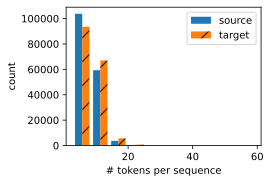

In [ ]:
#@ save
def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """Plot the histogram for list length pairs."""
    d2l.set_figsize()
    _, _, patches = d2l.plt.hist(
        [[len(l) for l in xlist], [len(l) for l in ylist]])
    d2l.plt.xlabel(xlabel)
    d2l.plt.ylabel(ylabel)
    for patch in patches[1].patches:
        patch.set_hatch('/')
    d2l.plt.legend(legend)

show_list_len_pair_hist(['source', 'target'], '# tokens per sequence',
                        'count', src, tgt);

### 10.5.3. Loading Sequences of Fixed Length

As we will explain later (Fig. 10.7.1), when training with target sequences, the decoder output (label tokens) can be the same decoder input (target tokens), shifted by one token; and the special beginning-of-sequence “&lt;bos&gt;” token will be used as the first input token for predicting the target sequence (Fig. 10.7.3).

---
牧之：这里的两个论断都没有理解，后续需要反刍理解。另外以下代码的返回值也没理解，目测也是与上述论断有关。

In [ ]:
@d2l.add_to_class(MTFraEng)  #@ save
def __init__(self, batch_size, num_steps=9, num_train=512, num_val=128):
    super(MTFraEng, self).__init__()
    self.save_hyperparameters()
    self.arrays, self.src_vocab, self.tgt_vocab = self._build_arrays(
        self._download())

@d2l.add_to_class(MTFraEng)  #@ save
def _build_arrays(self, raw_text, src_vocab=None, tgt_vocab=None):
    def _build_array(sentences, vocab, is_tgt=False):
        pad_or_trim = lambda seq, t: (
            seq[:t] if len(seq) > t else seq + ['<pad>'] * (t - len(seq)))
        sentences = [pad_or_trim(s, self.num_steps) for s in sentences]
        if is_tgt:
            sentences = [['<bos>'] + s for s in sentences]
        if vocab is None:
            vocab = d2l.Vocab(sentences, min_freq=2)
        array = torch.tensor([vocab[s] for s in sentences])
        valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
        return array, vocab, valid_len
    src, tgt = self._tokenize(self._preprocess(raw_text),
                              self.num_train + self.num_val)
    src_array, src_vocab, src_valid_len = _build_array(src, src_vocab)
    tgt_array, tgt_vocab, _ = _build_array(tgt, tgt_vocab, True)
    return ((src_array, tgt_array[:,:-1], src_valid_len, tgt_array[:,1:]),
            src_vocab, tgt_vocab)

### 10.5.4. Reading the Dataset

Finally, we define the `get_dataloader` method to return the data iterator.

In [ ]:
@d2l.add_to_class(MTFraEng)  #@ save
def get_dataloader(self, train):
    idx = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader(self.arrays, train, idx)

Let’s read the first minibatch from the English–French dataset.

In [ ]:
data = MTFraEng(batch_size=3)
src, tgt, src_valid_len, label = next(iter(data.train_dataloader()))
print('source:', src.type(torch.int32))
print('decoder input:', tgt.type(torch.int32))
print('source len excluding pad:', src_valid_len.type(torch.int32))
print('label:', label.type(torch.int32))

source: tensor([[ 84,  32, 120,   2,   3,   4,   4,   4,   4],
        [ 91, 191,   2,   3,   4,   4,   4,   4,   4],
        [155,   0,   3,   4,   4,   4,   4,   4,   4]], dtype=torch.int32)
decoder input: tensor([[  3, 108, 122, 183,  30,   6,   2,   4,   5],
        [  3,  69,   6,   2,   4,   5,   5,   5,   5],
        [  3,   6,   0,   4,   5,   5,   5,   5,   5]], dtype=torch.int32)
source len excluding pad: tensor([5, 4, 3], dtype=torch.int32)
label: tensor([[108, 122, 183,  30,   6,   2,   4,   5,   5],
        [ 69,   6,   2,   4,   5,   5,   5,   5,   5],
        [  6,   0,   4,   5,   5,   5,   5,   5,   5]], dtype=torch.int32)


We show a pair of source and target sequences processed by the above `_build_arrays` method (in the string format).

In [ ]:
@d2l.add_to_class(MTFraEng)  #@ save
def build(self, src_sentences, tgt_sentences):
    raw_text = '\n'.join([src + '\t' + tgt for src, tgt in zip(
        src_sentences, tgt_sentences)])
    arrays, _, _ = self._build_arrays(
        raw_text, self.src_vocab, self.tgt_vocab)
    return arrays

src, tgt, _,  _ = data.build(['hi .'], ['salut .'])
print('source:', data.src_vocab.to_tokens(src[0].type(torch.int32)))
print('target:', data.tgt_vocab.to_tokens(tgt[0].type(torch.int32)))

source: ['hi', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
target: ['<bos>', 'salut', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


### 10.5.5. Summary

In natural language processing, *machine translation* refers to the task of automatically mapping from a sequence representing a string of text in a *source* language to a string representing a plausible translation in a *target* language. Using word-level tokenization, the vocabulary size will be significantly larger than that using character-level tokenization, but the sequence lengths will be much shorter. To mitigate the large vocabulary size, we can treat infrequent tokens as some "unknown" token. We can truncate and pad text sequences so that all of them will have the same length to be loaded in minibatches. Modern implementations often bucket sequences with similar lengths to avoid wasting excessive computation on padding.

### 10.5.6. Exercises

1. Try different values of the `max_examples` argument in the `_tokenize` method. How does this affect the vocabulary sizes of the source language and the target language?

1. Text in some languages such as Chinese and Japanese does not have word boundary indicators (e.g., space). Is word-level tokenization still a good idea for such cases? Why or why not?

## 10.6. The Encoder–Decoder Architecture

In general sequence-to-sequence problems like machine translation (Section 10.5), inputs and outputs are of varying lengths that are unaligned. The standard approach to handling this sort of data is to design an *encoder--decoder* architecture (Fig. 10.6.1) consisting of two major components: an *encoder* that takes a variable-length sequence as input, and a *decoder* that acts as a conditional language model, taking in the encoded input and the leftwards context of the target sequence and predicting the subsequent token in the target sequence.

![](https://d2l.ai/_images/encoder-decoder.svg)
<center>Fig. 10.6.1 The encoder–decoder architecture.</center>

...

Since the encoder--decoder architecture forms the basis of different sequence-to-sequence models in subsequent sections, this section will convert this architecture into an interface that will be implemented later.

In [ ]:
from torch import nn
from d2l import torch as d2l

### 10.6.1. Encoder

In the encoder interface, we just specify that the encoder takes variable-length sequences as input `X`.

In [ ]:
class Encoder(nn.Module):  #@ save
    """The base encoder interface for the encoder--decoder architecture."""
    def __init__(self):
        super().__init__()

    # Later there can be additional arguments (e.g., length excluding padding)
    def forward(self, X, *args):
        raise NotImplementedError

### 10.6.2. Decoder

In the following decoder interface, we add an additional `init_state` method to convert the encoder output (`enc_all_outputs`) into the encoded state. Note that this step may require extra inputs, such as the valid length of the input, which was explained in Section 10.5. To generate a variable-length sequence token by token, every time the decoder may map an input (e.g., the generated token at the previous time step) and the encoded state into an output token at the current time step.

---
牧之：decoder 并不认为 encoder 的输出 `enc_all_outputs` 就是 encoded state，而是要经过 `init_state` 的转换。

In [ ]:
class Decoder(nn.Module):  #@ save
    """The base decoder interface for the encoder--decoder architecture."""
    def __init__(self):
        super().__init__()

    # Later there can be additional arguments (e.g., length excluding padding)
    def init_state(self, enc_all_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

### 10.6.3. Putting the Encoder and Decoder Together

In the forward propagation, the output of the encoder is used to produce the encoded state, and this state will be further used by the decoder as one of its input.

In [ ]:
class EncoderDecoder(d2l.Classifier):  #@ save
    """The base class for the encoder--decoder architecture."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_all_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_all_outputs, *args)
        # Return decoder output only
        return self.decoder(dec_X, dec_state)[0]

### 10.6.4. Summary

Encoder-decoder architectures can handle inputs and outputs that both consist of variable-length sequences and thus are suitable for sequence-to-sequence problems such as machine translation. The encoder takes a variable-length sequence as input and transforms it into a state with a fixed shape. The decoder maps the encoded state of a fixed shape to a variable-length sequence.

### 10.6.5. Exercises

1. Suppose that we use neural networks to implement the encoder--decoder architecture. Do the encoder and the decoder have to be the same type of neural network?

1. Besides machine translation, can you think of another application where the encoder--decoder architecture can be applied?

## 10.7. Sequence-to-Sequence Learning for Machine Translation

In so-called sequence-to-sequence problems such as machine translation (as discussed in Section 10.5), where inputs and outputs each consist of variable-length unaligned sequences, we generally rely on encoder–decoder architectures (Section 10.6). In this section, we will demonstrate the application of an encoder--decoder architecture, where both the encoder and decoder are implemented as RNNs, to the task of machine translation (Cho et al., 2014, Sutskever et al., 2014).

Here, the encoder RNN will take a variable-length sequence as input and transform it into a fixed-shape hidden state. Later, in Section 11, we will introduce attention mechanisms, which allow us to access encoded inputs without having to compress the entire input into a single fixed-length representation.

Then to generate the output sequence, one token at a time, the decoder model, consisting of a separate RNN, will predict each successive target token given both the input sequence and the preceding tokens in the output. During training, the decoder will typically be conditioned upon the preceding tokens in the official "ground truth" label. However, at test time, we will want to condition each output of the decoder on the tokens already predicted. Note that if we ignore the encoder, the decoder in a sequence-to-sequence architecture behaves just like a normal language model. Fig. 10.7.1 illustrates how to use two RNNs for sequence-to-sequence learning in machine translation.

![](http://d2l.ai/_images/seq2seq.svg)
<center>Fig. 10.7.1 Sequence-to-sequence learning with an RNN encoder and an RNN decoder.</center>

In Fig. 10.7.1, the special "&lt;eos&gt;" token marks the end of the sequence. Our model can stop making predictions once this token is generated. At the initial time step of the RNN decoder, there are two special design decisions to be aware of: First, we begin every input with a special beginning-of-sequence "&lt;bos&gt;" token. Second, we may feed the final hidden state of the encoder into the decoder at every single decoding time step (Cho et al., 2014). In some other designs, such as that of Sutskever et al. (2014), the final hidden state of the RNN encoder is used to initiate the hidden state of the decoder only at the first decoding step.

In [ ]:
import collections
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 10.7.1. Teacher Forcing

While running the encoder on the input sequence is relatively straightforward, handling the input and output of the decoder requires more care. The most common approach is sometimes called *teacher forcing*. Here, the original target sequence (token labels) is fed into the decoder as input. More concretely, the special beginning-of-sequence token and the original target sequence, excluding the final token, are concatenated as input to the decoder, while the decoder output (labels for training) is the original target sequence, shifted by one token (Fig. 10.7.1).

Our implementation in Section 10.5.3 prepared training data for teacher forcing, where shifting tokens for self-supervised learning is similar to the training of language models in Section 9.3. An alternative approach is to feed the *predicted* token from the previous time step as the current input to the decoder.

### 10.7.2. Encoder

Recall that the encoder transforms an input sequence of variable length into a fixed-shape *context variable* $\mathbf{c}$ (see Fig. 10.7.1).

Consider a single sequence example (batch size 1). Suppose the input sequence is $x_1, \ldots, x_T$, such that $x_t$ is the $t^{\textrm{th}}$ token. At time step $t$, the RNN transforms the input feature vector $\mathbf{x}_t$ for $x_t$ and the hidden state $\mathbf{h} _{t-1}$ from the previous time step into the current hidden state $\mathbf{h}_t$. We can use a function $f$ to express the transformation of the RNN's recurrent layer:

$$\mathbf{h}_t = f(\mathbf{x}_t, \mathbf{h}_{t-1}). $$

In general, the encoder transforms the hidden states at all time steps into a context variable through a customized function $q$:

$$\mathbf{c} =  q(\mathbf{h}_1, \ldots, \mathbf{h}_T).$$

For example, in Fig. 10.7.1, the context variable is just the hidden state $\mathbf{h}_T$ corresponding to the encoder RNN's representation after processing the final token of the input sequence.

In this example, we have used a unidirectional RNN to design the encoder, where the hidden state only depends on the input subsequence at and before the time step of the hidden state. We can also construct encoders using bidirectional RNNs. In this case, a hidden state depends on the subsequence before and after the time step (including the input at the current time step), which encodes the information of the entire sequence.

Now let's implement the RNN encoder. Note that we use an **embedding layer** to obtain the feature vector for each token in the input sequence. The weight of an embedding layer is a matrix, where the number of rows corresponds to the size of the input vocabulary (`vocab_size`) and number of columns corresponds to the feature vector's dimension (`embed_size`). For any input token index $i$, the embedding layer fetches the $i^{\textrm{th}}$ row (starting from 0) of the weight matrix to return its feature vector. Here we implement the encoder with a multilayer GRU.

In [ ]:
def init_seq2seq(module):  #@ save
    """Initialize weights for sequence-to-sequence learning."""
    if type(module) == nn.Linear:
         nn.init.xavier_uniform_(module.weight)
    if type(module) == nn.GRU:
        for param in module._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(module._parameters[param])

class Seq2SeqEncoder(d2l.Encoder):  #@ save
    """The RNN encoder for sequence-to-sequence learning."""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = d2l.GRU(embed_size, num_hiddens, num_layers, dropout)
        self.apply(init_seq2seq)

    def forward(self, X, *args):
        # X shape: (batch_size, num_steps)
        embs = self.embedding(X.t().type(torch.int64))
        # embs shape: (num_steps, batch_size, embed_size)
        outputs, state = self.rnn(embs)
        # outputs shape: (num_steps, batch_size, num_hiddens)
        # state shape: (num_layers, batch_size, num_hiddens)
        return outputs, state

---
牧之：
- 如果不清楚不同类型网络的参数组织方式，可以尝试通过如下代码来打印获取。

  ```
  for name, param in module.named_parameters():
      print(name)
  ```
- 这里的 Embedding 是否是取代了 OneHot 编码？`self.embedding` 是定义了参数，这些参数稍后也是可以学习的吗？
  - 通义：是的，`nn.Embedding` 层确实是用来替代传统意义上的 One-Hot 编码的，尤其是在处理文本数据、词汇表到向量映射的场景下。One-Hot 编码会为每个词创建一个与词汇表大小相同的向量，除了对应的词位置为 1，其余均为 0，这种方式虽然简单直观，但在高维空间中会造成大量的稀疏性和计算效率低下问题。而 `nn.Embedding` 通过学习词向量的方式，能够捕获词与词之间的语义关系，形成低维稠密向量，这在很多自然语言处理任务中能带来性能提升。在以上代码片段中，`self.embedding = nn.Embedding(vocab_size, embed_size)` 这行代码定义了一个嵌入层，它将词汇表中的每个词（大小为 `vocab_size`）映射到一个固定大小的向量（维度为 `embed_size`）。这些向量是模型的可学习参数，意味着在训练过程中，通过反向传播和优化算法（如 SGD、Adam 等），这些嵌入向量的值会不断调整，以最小化预定义的损失函数。因此，每个词最终对应的嵌入向量是能够捕捉该词在上下文中的意义并有助于预测任务的，这些参数是模型学习的关键部分之一。总结来说，`nn.Embedding` 不仅用以替代 One-Hot 编码，还引入了词向量的概念，这些词向量作为模型的一部分，会在训练过程中不断优化，以更好地表达词语的意义和上下文信息。
- 注意，`self.embedding` 把 `(batch_size, num_steps)` 形状转换成 `(num_steps, batch_size, num_inputs)` 形状，这样就和之前 One-Hot 编码实现的版本输入输出形状兼容了。

Let's use a concrete example to illustrate the above encoder implementation. Below, we instantiate a two-layer GRU encoder whose number of hidden units is 16. Given a minibatch of sequence inputs `X` (batch size $=4$; number of time steps $=9$), the hidden states of the final layer at all the time steps (`enc_outputs` returned by the encoder's recurrent layers) are a tensor of shape (number of time steps, batch size, number of hidden units).

In [ ]:
vocab_size, embed_size, num_hiddens, num_layers = 10, 8, 16, 2
batch_size, num_steps = 4, 9
encoder = Seq2SeqEncoder(vocab_size, embed_size, num_hiddens, num_layers)
X = torch.zeros((batch_size, num_steps))
enc_outputs, enc_state = encoder(X)
d2l.check_shape(enc_outputs, (num_steps, batch_size, num_hiddens))

Since we are using a GRU here, the shape of the multilayer hidden states at the final time step is (number of hidden layers, batch size, number of hidden units).

In [ ]:
d2l.check_shape(enc_state, (num_layers, batch_size, num_hiddens))

### 10.7.3. Decoder

Given a target output sequence $y_1, y_2, \ldots, y_{T'}$ for each time step $t'$ (we use $t^\prime$ to differentiate from the input sequence time steps), the decoder assigns a predicted probability to each possible token occurring at step $y_{t'+1}$ conditioned upon the previous tokens in the target $y_1, \ldots, y_{t'}$ and the context variable $\mathbf{c}$, i.e., $P(y_{t'+1} \mid y_1, \ldots, y_{t'}, \mathbf{c})$.

To predict the subsequent token $t^\prime+1$ in the target sequence, the RNN decoder takes the previous step's target token $y_{t^\prime}$, the hidden RNN state from the previous time step $\mathbf{s}_{t^\prime-1}$, and the context variable $\mathbf{c}$ as its input, and transforms them into the hidden state $\mathbf{s}_{t^\prime}$ at the current time step. We can use a function $g$ to express the transformation of the decoder's hidden layer:

$$\mathbf{s}_{t^\prime} = g(y_{t^\prime-1}, \mathbf{c}, \mathbf{s}_{t^\prime-1}). \tag{10.7.3}$$

After obtaining the hidden state of the decoder, we can use an output layer and the softmax operation to compute the predictive distribution $p(y_{t^{\prime}+1} \mid y_1, \ldots, y_{t^\prime}, \mathbf{c})$ over the subsequent output token ${t^\prime+1}$.

Following Fig. 10.7.1, when implementing the decoder as follows, we directly use the hidden state at the final time step of the encoder to initialize the hidden state of the decoder. This requires that the RNN encoder and the RNN decoder have *the same number of layers and hidden units*. To further incorporate the encoded input sequence information, the context variable is concatenated with the decoder input at all the time steps. To predict the probability distribution of the output token, we use a fully connected layer to transform the hidden state at the final layer of the RNN decoder.

In [ ]:
class Seq2SeqDecoder(d2l.Decoder):
    """The RNN decoder for sequence to sequence learning."""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = d2l.GRU(embed_size+num_hiddens, num_hiddens,
                           num_layers, dropout)
        self.dense = nn.LazyLinear(vocab_size)
        self.apply(init_seq2seq)

    def init_state(self, enc_all_outputs, *args):
        return enc_all_outputs

    def forward(self, X, state):
        # X shape: (batch_size, num_steps)
        # embs shape: (num_steps, batch_size, embed_size)
        embs = self.embedding(X.t().type(torch.int32))
        enc_output, hidden_state = state
        # context shape: (batch_size, num_hiddens)
        context = enc_output[-1]
        # Broadcast context to (num_steps, batch_size, num_hiddens)
        context = context.repeat(embs.shape[0], 1, 1)
        # Concat at the feature dimension
        embs_and_context = torch.cat((embs, context), -1)
        outputs, hidden_state = self.rnn(embs_and_context, hidden_state)
        outputs = self.dense(outputs).swapaxes(0, 1)
        # outputs shape: (batch_size, num_steps, vocab_size)
        # hidden_state shape: (num_layers, batch_size, num_hiddens)
        return outputs, [enc_output, hidden_state]

---
牧之：`enc_output` 的形状为 `(num_steps, batch_size, num_hiddens)`；`hidden_state` 的形状为
`(num_layers, batch_size, num_hiddens)`。

To illustrate the implemented decoder, below we instantiate it with the same hyperparameters from the aforementioned encoder. As we can see, the output shape of the decoder becomes (batch size, number of time steps, vocabulary size), where the final dimension of the tensor stores the predicted token distribution.

In [ ]:
decoder = Seq2SeqDecoder(vocab_size, embed_size, num_hiddens, num_layers)
state = decoder.init_state(encoder(X))
dec_outputs, state = decoder(X, state)
d2l.check_shape(dec_outputs, (batch_size, num_steps, vocab_size))
d2l.check_shape(state[1], (num_layers, batch_size, num_hiddens))

/home/lancer/miniforge3/envs/d2l/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


The layers in the above RNN encoder–decoder model are summarized in Fig. 10.7.2.

![](https://d2l.ai/_images/seq2seq-details.svg)
<center>Fig. 10.7.2 Layers in an RNN encoder--decoder model.</center>

### 10.7.4. Encoder–Decoder for Sequence-to-Sequence Learning

In [ ]:
class Seq2Seq(d2l.EncoderDecoder):  #@ save
    """The RNN encoder--decoder for sequence to sequence learning."""
    def __init__(self, encoder, decoder, tgt_pad, lr):
        super().__init__(encoder, decoder)
        self.save_hyperparameters()

    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)

    def configure_optimizers(self):
        # Adam optimizer is used here
        return torch.optim.Adam(self.parameters(), lr=self.lr)

### 10.7.5. Loss Function with Masking

At each time step, the decoder predicts a probability distribution for the output tokens. As with language modeling, we can apply softmax to obtain the distribution and calculate the cross-entropy loss for optimization. Recall from Section 10.5 that the special padding tokens are appended to the end of sequences and so sequences of varying lengths can be efficiently loaded in minibatches of the same shape. However, prediction of padding tokens should be excluded from loss calculations. To this end, we can mask irrelevant entries with zero values so that multiplication of any irrelevant prediction with zero equates to zero.

In [ ]:
@d2l.add_to_class(Seq2Seq)
def loss(self, Y_hat, Y):
    l = super(Seq2Seq, self).loss(Y_hat, Y, averaged=False)
    mask = (Y.reshape(-1) != self.tgt_pad).type(torch.float32)
    return (l * mask).sum() / mask.sum()

---
牧之：这个 `reshape(-1)` 有什么意义吗？

### 10.7.6. Training

Now we can create and train an RNN encoder–decoder model for sequence-to-sequence learning on the machine translation dataset.

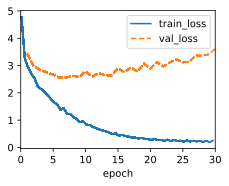

In [ ]:
data = d2l.MTFraEng(batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 2, 0.2
encoder = Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                lr=0.005)
trainer = d2l.Trainer(max_epochs=30, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 10.7.7. Prediction

To predict the output sequence at each step, the predicted token from the previous time step is fed into the decoder as an input. One simple strategy is to sample whichever token that has been assigned by the decoder the highest probability when predicting at each step. As in training, at the initial time step the beginning-of-sequence ("&lt;bos&gt;") token is fed into the decoder. This prediction process is illustrated  in Fig. 10.7.3. When the end-of-sequence ("&lt;eos&gt;") token is predicted, the prediction of the output sequence is complete.

![](https://d2l.ai/_images/seq2seq-predict.svg)
<center>Fig. 10.7.3 Predicting the output sequence token by token using an RNN encoder--decoder.</center>

In the next section, we will introduce more sophisticated strategies based on beam search (Section 10.8).

In [ ]:
@d2l.add_to_class(d2l.EncoderDecoder)  #@ save
def predict_step(self, batch, device, num_steps,
                 save_attention_weights=False):
    batch = [a.to(device) for a in batch]
    src, tgt, src_valid_len, _ = batch
    enc_all_outputs = self.encoder(src, src_valid_len)
    dec_state = self.decoder.init_state(enc_all_outputs, src_valid_len)
    outputs, attention_weights = [tgt[:, (0)].unsqueeze(1), ], []
    for _ in range(num_steps):
        Y, dec_state = self.decoder(outputs[-1], dec_state)
        outputs.append(Y.argmax(2))
        # Save attention weights (to be covered later)
        if save_attention_weights:
            attention_weights.append(self.decoder.attention_weights)
    return torch.cat(outputs[1:], 1), attention_weights

### 10.7.8. Evaluation of Predicted Sequences

We can evaluate a predicted sequence by comparing it with the target sequence (the ground truth). But what precisely is the appropriate measure for comparing similarity between two sequences?

Bilingual Evaluation Understudy (BLEU), though originally proposed for evaluating machine translation results (Papineni et al., 2002), has been extensively used in measuring the quality of output sequences for different applications. In principle, for any $n$-gram (Section 9.3.1.1) in the predicted sequence, BLEU evaluates whether this $n$-gram appears in the target sequence.

Denote by $p_n$ the precision of an $n$-gram, defined as the ratio of the number of matched $n$-grams in the predicted and target sequences to the number of $n$-grams in the predicted sequence. To explain, given a target sequence $A$, $B$, $C$, $D$, $E$, $F$, and a predicted sequence $A$, $B$, $B$, $C$, $D$, we have $p_1 = 4/5$,  $p_2 = 3/4$, $p_3 = 1/3$, and $p_4 = 0$. Now let $\textrm{len}_{\textrm{label}}$ and $\textrm{len}_{\textrm{pred}}$ be the numbers of tokens in the target sequence and the predicted sequence, respectively. Then, BLEU is defined as

$$ \exp\left(\min\left(0, 1 - \frac{\textrm{len}_{\textrm{label}}}{\textrm{len}_{\textrm{pred}}}\right)\right) \prod_{n=1}^k p_n^{1/2^n}, \tag{10.7.4}$$

where $k$ is the longest $n$-gram for matching.

Based on the definition of BLEU in (10.7.4), whenever the predicted sequence is the same as the target sequence, BLEU is 1. Moreover, since matching longer $n$-grams is more difficult, BLEU assigns a greater weight when a longer $n$-gram has high precision. Specifically, when $p_n$ is fixed, $p_n^{1/2^n}$ increases as $n$ grows (the original paper uses $p_n^{1/n}$). Furthermore, since predicting shorter sequences tends to yield a higher $p_n$ value, the coefficient before the multiplication term in (10.7.4) penalizes shorter predicted sequences. For example, when $k=2$, given the target sequence $A$, $B$, $C$, $D$, $E$, $F$ and the predicted sequence $A$, $B$, although $p_1 = p_2 = 1$, the penalty factor $\exp(1-6/2) \approx 0.14$ lowers the BLEU.

We implement the BLEU measure as follows.

In [ ]:
def bleu(pred_seq, label_seq, k):  #@ save
    """Compute the BLEU."""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    for n in range(1, min(k, len_pred) + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

In the end, we use the trained RNN encoder–decoder to translate a few English sentences into French and compute the BLEU of the results.

In [ ]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['il', 'est', 'mouillé', '.'], bleu,0.658
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


### 10.7.9. Summary

Following the design of the encoder--decoder architecture, we can use two RNNs to design a model for sequence-to-sequence learning. In encoder--decoder training, the teacher forcing approach feeds original output sequences (in contrast to predictions) into the decoder. When implementing the encoder and the decoder, we can use multilayer RNNs. We can use masks to filter out irrelevant computations, such as when calculating the loss. For evaluating output sequences, BLEU is a popular measure that matches $n$-grams between the predicted sequence and the target sequence.

### 10.7.10. Exercises

1. Can you adjust the hyperparameters to improve the translation results?
1. Rerun the experiment without using masks in the loss calculation. What results do you observe? Why?
1. If the encoder and the decoder differ in the number of layers or the number of hidden units, how can we initialize the hidden state of the decoder?
1. In training, replace teacher forcing with feeding the prediction at the previous time step into the decoder. How does this influence the performance?
1. Rerun the experiment by replacing GRU with LSTM.
1. Are there any other ways to design the output layer of the decoder?

## 10.8. Beam Search

In this section, we will begin by formalizing this *greedy search* strategy and identifying some problems that practitioners tend to run into. Subsequently, we compare this strategy with two alternatives: *exhaustive search* (illustrative but not practical) and *beam search* (the standard method in practice).

### 10.8.1. Greedy Search

Consider the simple *greedy search* strategy from Section 10.7. Here, at any time step $t'$, we simply select the token with the highest conditional probability from $\mathcal{Y}$, i.e.,

$$y_{t'} = \operatorname*{argmax}_{y \in \mathcal{Y}} P(y \mid y_1, \ldots, y_{t'-1}, \mathbf{c}). \tag{10.8.1}$$

Once our model outputs "&lt;eos&gt;" (or we reach the maximum length $T'$) the output sequence is completed.

...

However, if we put aside efficiency for a minute, it might seem more reasonable to search for the *most likely sequence*, not the sequence of (greedily selected) *most likely tokens*. It turns out that these two objects can be quite different. The most likely sequence is the one that maximizes the expression $\prod_{t'=1}^{T'} P(y_{t'} \mid y_1, \ldots, y_{t'-1}, \mathbf{c})$.

...

### 10.8.2. Exhaustive Search

If the goal is to obtain the most likely sequence, we may consider using *exhaustive search*: enumerate all the possible output sequences with their conditional probabilities, and then output the one that scores the highest predicted probability.

While this would certainly give us what we desire, it would come at a prohibitive computational cost of $\mathcal{O}(\left|\mathcal{Y}\right|^{T'})$, exponential in the sequence length and with an enormous base given by the vocabulary size.

### 10.8.3. Beam Search

You could view sequence decoding strategies as lying on a spectrum, with *beam search* striking a compromise between the efficiency of greedy search and the optimality of exhaustive search. The most straightforward version of beam search is characterized by a single hyperparameter, the *beam size*, $k$. Let's explain this terminology. At time step 1, we select the $k$ tokens with the highest predicted probabilities. Each of them will be the first token of $k$ candidate output sequences, respectively. At each subsequent time step, based on the $k$ candidate output sequences at the previous time step, we continue to select $k$ candidate output sequences with the highest predicted probabilities from $k\left|\mathcal{Y}\right|$ possible choices.

![](https://d2l.ai/_images/beam-search.svg)
<center>Fig. 10.8.3  The process of beam search (beam size $=2$; maximum length of an output sequence $=3$). The candidate output sequences are $\mathit{A}$, $\mathit{C}$, $\mathit{AB}$, $\mathit{CE}$, $\mathit{ABD}$, and $\mathit{CED}$.</center>

Fig. 10.8.3 demonstrates the process of beam search with an example.

...

As a result, we get six candidates output sequences: (i) $A$; (ii) $C$; (iii) $A$, $B$; (iv) $C$, $E$; (v) $A$, $B$, $D$; and (vi) $C$, $E$, $D$.

In the end, we obtain the set of final candidate output sequences based on these six sequences (e.g., discard portions including and after “&lt;eos&gt;”). Then we choose the output sequence which maximizes the following score:

$$ \frac{1}{L^\alpha} \log P(y_1, \ldots, y_{L}\mid \mathbf{c}) = \frac{1}{L^\alpha} \sum_{t'=1}^L \log P(y_{t'} \mid y_1, \ldots, y_{t'-1}, \mathbf{c}); \tag{10.8.4}$$

here $L$ is the length of the final candidate sequence and $\alpha$ is usually set to 0.75. Since a longer sequence has more logarithmic terms in the summation of (10.8.4), the term $L^\alpha$ in the denominator penalizes long sequences.

The computational cost of beam search is $\mathcal{O}(k\left|\mathcal{Y}\right|T')$. This result is in between that of greedy search and that of exhaustive search. Greedy search can be treated as a special case of beam search arising when the beam size is set to 1.

---
牧之：概率值的范围 $[0,1]$，所以每个概率值的对数值均为非正数。增加一个非正数，总体值倾向于越来越小，但是由于第一项的存在，当多预测一个值时，这个总体负数会被绝对值缩小，也就是变大了。所以，可以用这个式子来计算各个序列的相对大小排序。

### 10.8.4. Summary

Sequence searching strategies include greedy search, exhaustive search, and beam search. Beam search provides a trade-off between accuracy and computational cost via the flexible choice of the beam size.

### 10.8.5. Exercises

1. Can we treat exhaustive search as a special type of beam search? Why or why not?
1. Apply beam search in the machine translation problem Section 10.7. How does the beam size affect the translation results and the prediction speed?
1. We used language modeling for generating text following  user-provided prefixes in Section 9.5. Which kind of search strategy does it use? Can you improve it?